# Preview Data
Load a few images, form a few interferograms and phase triplets

In [3]:
import glob
import rasterio
from scipy.ndimage import uniform_filter
from scipy.stats import pearsonr
import os
import numpy as np
from matplotlib import pyplot as plt

## Interferograms (Quad Pol)

['/data2/rb894/SAR/NISAR/delta_quad/HH/./20251121_HH.tif', '/data2/rb894/SAR/NISAR/delta_quad/HH/./20251215_HH.tif']


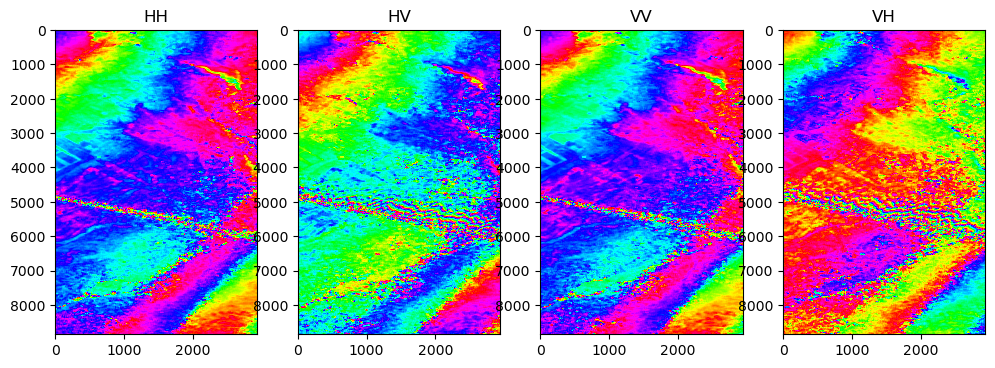

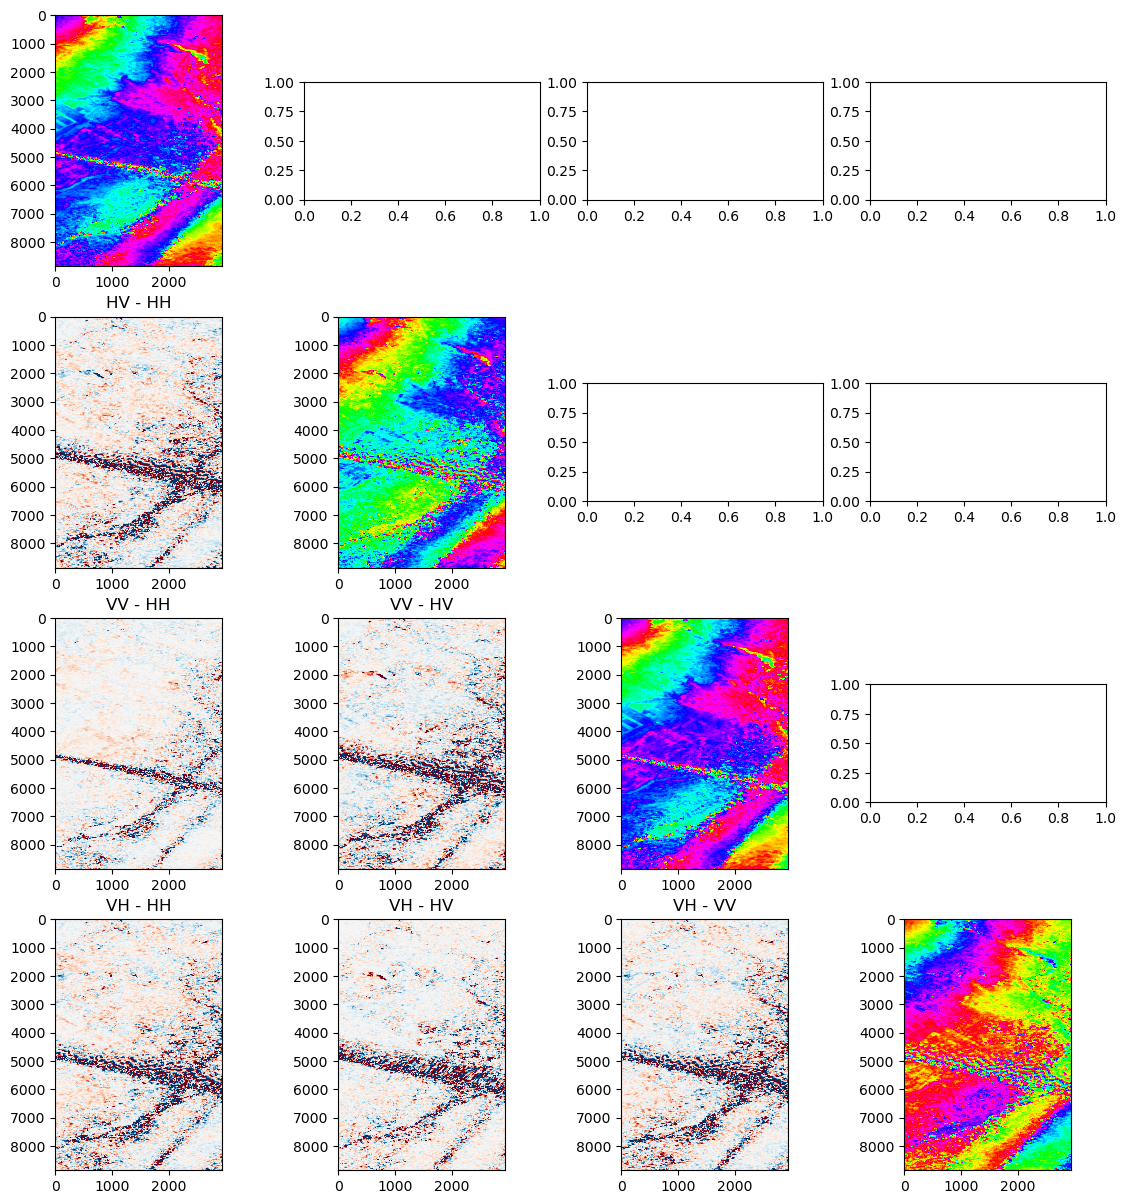

In [18]:
download_folder = '/data2/rb894/SAR/NISAR/delta_quad'
polarizations = ['HH', 'HV', 'VV', 'VH']

print(gslc_paths_HH)

pairs = [[0, 1]]

for pair in pairs:
    ml_size = (50, 50)

    infgms = []

    fig, ax = plt.subplots(nrows=1, ncols=len(polarizations), figsize=(12, 8))
    for pol,i in zip(polarizations, range(len(polarizations))):

        gslc_paths = sorted(glob.glob(os.path.join(download_folder, pol, './*.tif')))

        slc1 = rasterio.open(gslc_paths[pair[0]]).read(1)#[1500:3500, 2000:4000]
        slc2 = rasterio.open(gslc_paths[pair[1]]).read(1)#[1500:3500, 2000:4000]

        infgm = uniform_filter(slc2 * slc1.conj(), size=ml_size)
        infgms.append(infgm)

        ax[i].imshow(np.angle(infgm), vmin=-np.pi, vmax=np.pi, cmap='hsv', interpolation='none')
        ax[i].set_title(pol)
        ax[i].set_aspect(1/2)
    plt.show()


    fig, ax = plt.subplots(nrows=len(polarizations), ncols=len(polarizations), figsize=(14, 15))
    for pol1, i in zip(polarizations, range(len(polarizations))):
        for pol2, j in zip(polarizations, range(len(polarizations))):
            if i == j:
                ax[i, j].imshow(np.angle(infgms[i]), vmin=-np.pi, vmax=np.pi, cmap='hsv', interpolation='none')
            elif j < i:
                cross_infgm = uniform_filter(infgms[i] * infgms[j].conj(), size=(5, 5))
                cross_infgm *= np.mean(cross_infgm).conj()
                ax[i, j].imshow(np.angle(cross_infgm), vmin=-np.pi/2, vmax=np.pi/2, cmap='RdBu_r', interpolation='none')
                ax[i, j].set_title(f'{pol1} - {pol2}')
            ax[i, j].set_aspect(1/2)
    plt.show()

PearsonRResult(statistic=-0.58985275, pvalue=0.0)


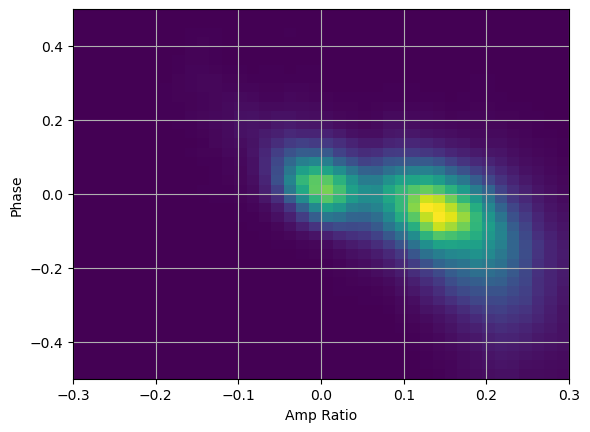

In [52]:
r = pearsonr(amp_ratio.flatten(), np.angle(infgm_HV * infgm_HH.conj()).flatten())
print(r)
plt.hist2d(amp_ratio.flatten(), np.angle(infgm_HV * infgm_HH.conj()).flatten(), bins=40, range=[[-0.3, 0.3], [-0.5, 0.5]])
plt.xlabel('Amp Ratio')
plt.ylabel('Phase')
plt.grid()
plt.show()

## Phase Triplets

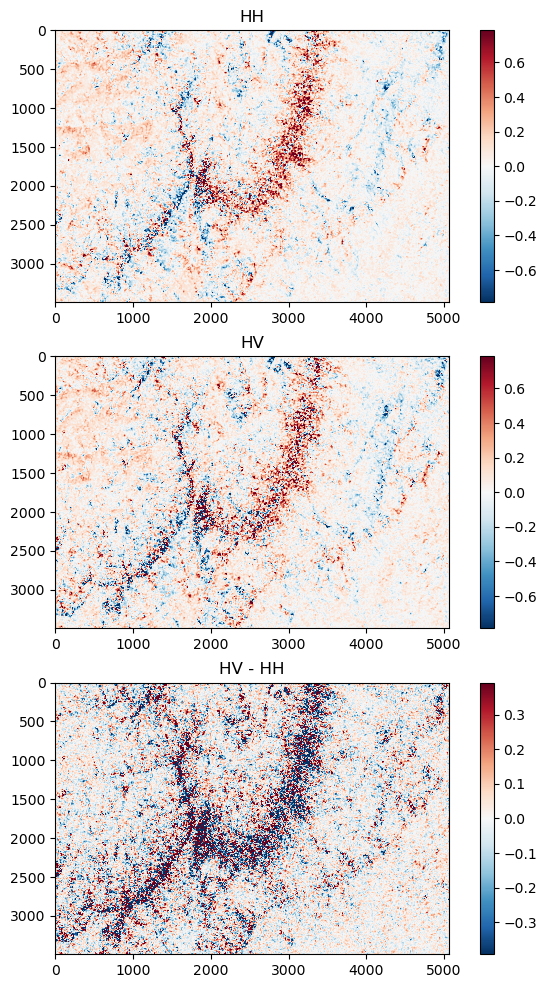

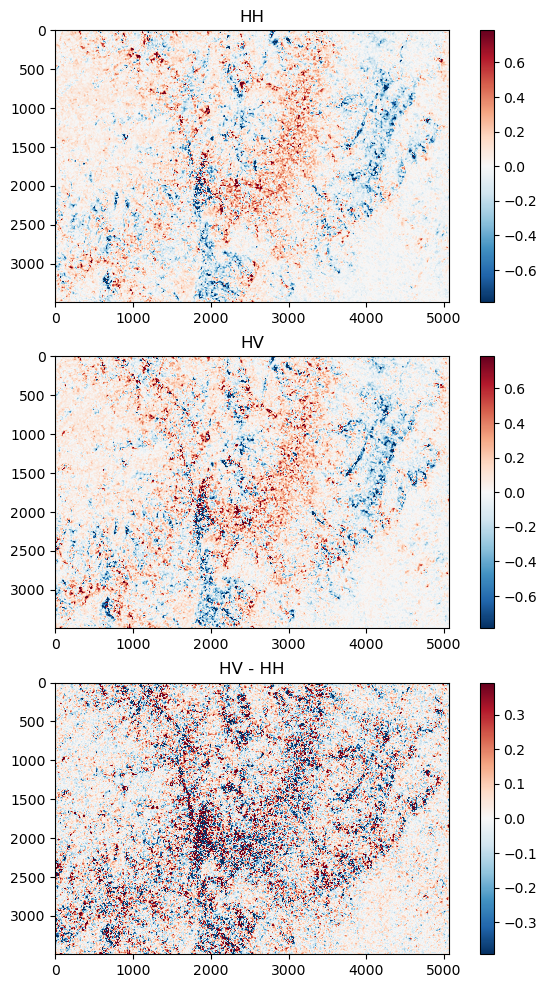

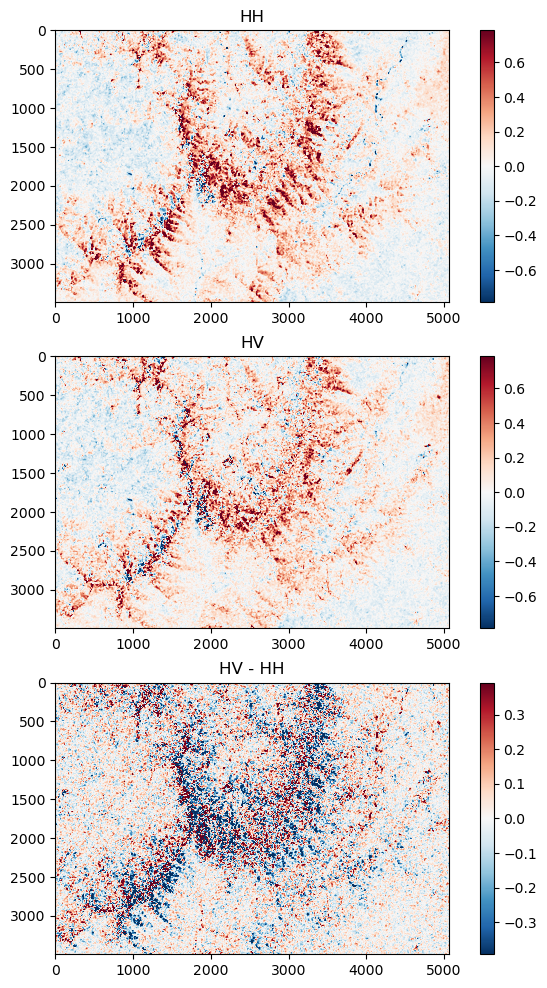

In [7]:
triplets = [[1, 2, 3], [2, 3, 4], [1, 3, 4]]

for tr in triplets:
    slc1 = rasterio.open(gslc_paths_HH[tr[0]]).read(1)
    slc2 = rasterio.open(gslc_paths_HH[tr[1]]).read(1)
    slc3 = rasterio.open(gslc_paths_HH[tr[2]]).read(1)

    infgm_HH_1 = uniform_filter(slc2 * slc1.conj(), size=(20, 20))
    infgm_HH_2 = uniform_filter(slc3 * slc2.conj(), size=(20, 20))
    infgm_HH_3 = uniform_filter(slc3 * slc1.conj(), size=(20, 20))
    triplet_HH = uniform_filter(infgm_HH_1 * infgm_HH_2 * infgm_HH_3.conj(), size=(10, 10))

    slc1 = rasterio.open(gslc_paths_HV[tr[0]]).read(1)
    slc2 = rasterio.open(gslc_paths_HV[tr[1]]).read(1)
    slc3 = rasterio.open(gslc_paths_HV[tr[2]]).read(1)

    infgm_HV_1 = uniform_filter(slc2 * slc1.conj(), size=(20, 20))
    infgm_HV_2 = uniform_filter(slc3 * slc2.conj(), size=(20, 20))
    infgm_HV_3 = uniform_filter(slc3 * slc1.conj(), size=(20, 20))
    triplet_HV = uniform_filter(infgm_HV_1 * infgm_HV_2 * infgm_HV_3.conj(), size=(10, 10))
    
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 12))
    im = ax[0].imshow(np.angle(triplet_HH), vmin=-np.pi/4, vmax=np.pi/4, interpolation='none', cmap='RdBu_r')
    plt.colorbar(im, ax=ax[0])
    ax[0].set_title('HH')
    im = ax[1].imshow(np.angle(triplet_HV), vmin=-np.pi/4, vmax=np.pi/4, interpolation='none', cmap='RdBu_r')
    ax[1].set_title('HV')
    plt.colorbar(im, ax=ax[1])
    im = ax[2].imshow(np.angle(triplet_HV * triplet_HH.conj()), vmin=-np.pi/8, vmax=np.pi/8, interpolation='none', cmap='RdBu_r')
    ax[2].set_title('HV - HH')
    plt.colorbar(im, ax=ax[2])

    plt.show()
